# 2. EXPLORATORY DATA ANALYSIS (EDA)
## HairBright · Marketing Mix Modeling — Revenue Prediction

---

**Input:** `data/interim/hairbright_clean_YYYYMMDD.xlsx`  
*Weekly-aggregated clean dataset produced by notebook 01.*

**Output:** Analytical insights, visualizations and feature selection criteria for notebook 03 (MMM transformation).

---
## 2.1. INITIAL SETUP

We import the necessary libraries and establish the connection with Google Drive.

**Libraries used:**
- `pandas`: Data manipulation
- `numpy`: Numerical operations
- `matplotlib` / `seaborn`: Static visualizations
- `pathlib`: File path management
- `warnings`: Suppress non-critical warnings

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Pandas display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f"Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
Pandas version: 2.2.2


In [2]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project paths
PATH_PROJECT = Path(
    '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
    'marketing-mix-modeling-beauty'
)
PATH_DATA_INTERIM   = PATH_PROJECT / 'data' / 'interim'
PATH_DATA_PROCESSED = PATH_PROJECT / 'data' / 'processed'

PATH_DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Project paths:")
print(f"  Interim   : {PATH_DATA_INTERIM}")
print(f"  Processed : {PATH_DATA_PROCESSED}")

Mounted at /content/drive
Project paths:
  Interim   : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/interim
  Processed : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/processed


---
## 2.2. DATA LOADING

We load the most recent clean file from the `interim` folder — the output of notebook 01.
The `sorted()` call ensures we always pick the latest version when multiple date-stamped files exist.


In [3]:
# Load most recent interim file
interim_files = sorted(PATH_DATA_INTERIM.glob('hairbright_clean_*.xlsx'))
assert len(interim_files) > 0, "No interim files found — run notebook 01 first."

FILE_CLEAN = interim_files[-1]
df = pd.read_excel(FILE_CLEAN, parse_dates=['week'])

print(f"File loaded  : {FILE_CLEAN.name}")
print(f"Dimensions   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Week range   : {df['week'].min().date()} → {df['week'].max().date()}")
print(f"Total weeks  : {df['week'].nunique()}")

# ── Spend scale validation ────────────────────────────────────────────────────
# Weekly spend values are expected to be below $1,000,000 per channel.
# Halt immediately if any column exceeds this threshold.
SPEND_COLS_ALL = ['spend_ps', 'spend_pmax', 'spend_display',
                  'spend_video', 'spend_fb', 'spend_ig', 'spend_meta_other']
for _col in SPEND_COLS_ALL:
    if _col in df.columns:
        _max = df[_col].max()
        assert _max < 1e6, (
            f"Scale error in '{_col}': max = {_max:,.0f} "
            f"(expected < 1,000,000 USD). Re-run notebook 01."
        )
print("Spend scale validation : all columns within expected USD range ✓")

# ── Derived columns ───────────────────────────────────────────────────────────
# spend_total, roas_total and cac are not stored in the interim file.
df['spend_total'] = df[SPEND_COLS_ALL].sum(axis=1)
df['roas_total']  = df['revenue'] / df['spend_total'].replace(0, float('nan'))
df['cac']         = df['spend_total'] / df['orders_total'].replace(0, float('nan'))

print(f"spend_total range : ${df['spend_total'].min():,.2f} – ${df['spend_total'].max():,.2f}/week")
print(f"Overall ROAS      : {df['revenue'].sum() / df['spend_total'].sum():.2f}x")


File loaded  : hairbright_clean_20260415.xlsx
Dimensions   : 74 rows × 43 columns
Week range   : 2022-07-25 → 2023-12-18
Total weeks  : 74
Spend scale validation : all columns within expected USD range ✓
spend_total range : $1,108.10 – $18,029.20/week
Overall ROAS      : 12.78x


---
## 2.3. DESCRIPTIVE STATISTICS

**What:** Summary statistics for the key KPIs and spend variables.  
**Why:** Establishes the baseline distribution of each variable — mean, spread and extremes — before any transformation. High CV% (coefficient of variation) signals variables with volatile weekly behavior that will require careful treatment in the MMM.

In [4]:
# Key variables for descriptive summary
KEY_VARS = ['revenue', 'orders_total', 'units_total', 'spend_total',
            'spend_ps', 'spend_pmax', 'spend_fb', 'spend_ig',
            'spend_display', 'spend_video', 'roas_total', 'cac']

stats = df[KEY_VARS].agg(['min','mean','median','max','std']).T
stats['cv_pct'] = (stats['std'] / stats['mean'] * 100).round(1)
stats.columns = ['Min', 'Mean', 'Median', 'Max', 'Std Dev', 'CV%']

print("Descriptive statistics — key variables")
print("-" * 70)
print(stats.to_string())

Descriptive statistics — key variables
----------------------------------------------------------------------
                    Min      Mean    Median        Max   Std Dev    CV%
revenue       10,339.78 56,528.93 42,744.61 474,930.36 58,461.22 103.40
orders_total      83.00    380.58    273.00   2,385.00    342.13  89.90
units_total      106.00    535.92    369.00   3,355.00    511.74  95.50
spend_total    1,108.10  4,421.97  3,456.27  18,029.20  3,506.94  79.30
spend_ps          25.61    512.03    425.14   2,932.58    443.14  86.50
spend_pmax         0.00  2,504.22  2,149.20  11,705.98  2,038.81  81.40
spend_fb           0.00  1,280.48  1,024.10   6,065.36  1,567.12 122.40
spend_ig           0.00     85.43      0.00   1,931.79    321.68 376.60
spend_display      0.00     27.70      0.00     404.31     78.62 283.90
spend_video        0.00     10.53      0.00     203.08     37.79 358.70
roas_total         3.63     15.39     14.51      47.16      8.93  58.10
cac                4.04   

---
## 2.4. REVENUE ANALYSIS

### 2.4.1. Revenue time series

**What:** Weekly revenue plotted over the full 74-week period with Q4 and Black Friday periods highlighted.  
**Why:** Identifies trend, seasonality and structural breaks. Spikes outside the highlighted periods may indicate data anomalies or untracked events that need to be controlled for in the MMM.

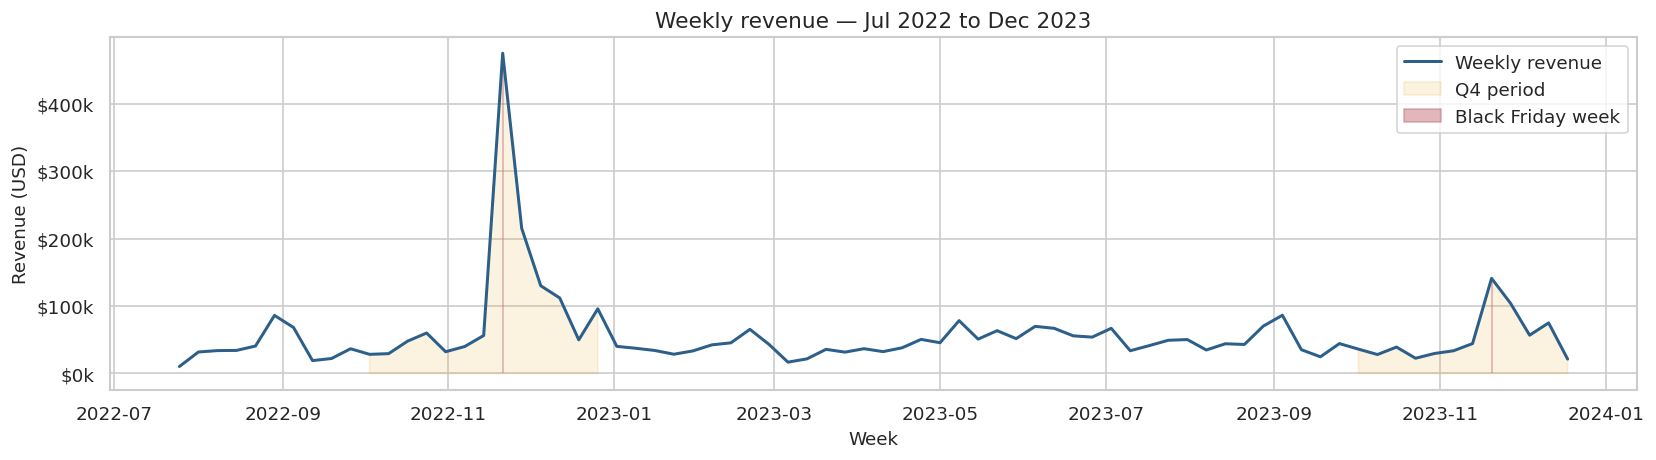

Peak week    : 2022-11-21 — $474,930
Lowest week  : 2022-07-25 — $10,340
Mean revenue : $56,529
CV%           : 103.4%%  (high volatility)


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['week'], df['revenue'], color='#2C5F8A', linewidth=1.8, label='Weekly revenue')
ax.fill_between(df['week'], df['revenue'],
                where=df['is_q4'] == 1,
                alpha=0.15, color='#E5A82E', label='Q4 period')
ax.fill_between(df['week'], df['revenue'],
                where=df['is_bf_week'] == 1,
                alpha=0.5, color='#C4707A', label='Black Friday week')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Week')
ax.set_ylabel('Revenue (USD)')
ax.set_title('Weekly revenue — Jul 2022 to Dec 2023')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak week    : {df.loc[df['revenue'].idxmax(), 'week'].date()} — ${df['revenue'].max():,.0f}")
print(f"Lowest week  : {df.loc[df['revenue'].idxmin(), 'week'].date()} — ${df['revenue'].min():,.0f}")
print(f"Mean revenue : ${df['revenue'].mean():,.0f}")
print(f"CV%           : {df['revenue'].std() / df['revenue'].mean() * 100:.1f}%%  (high volatility)")

### 2.4.2. Revenue distribution

**What:** Histogram and boxplot of weekly revenue.  
**Why:** A right-skewed distribution (expected given the Black Friday peak) confirms that log-transformation of the target variable is appropriate before modelling. A near-normal distribution would not require it.

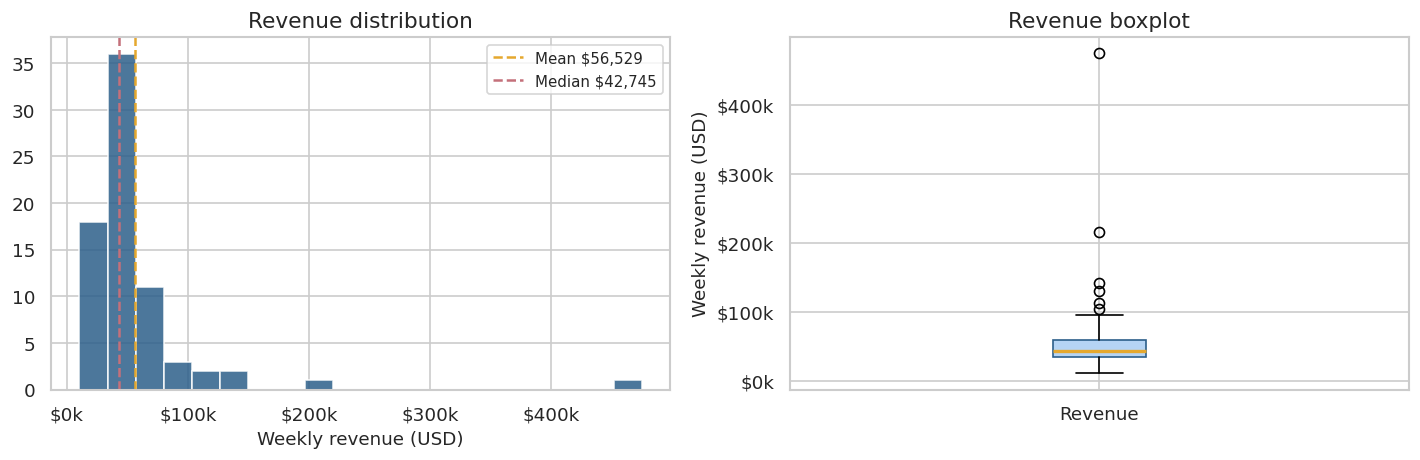

Skewness: 5.49 — right-skewed → log-transformation recommended ✓


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['revenue'], bins=20, color='#2C5F8A', edgecolor='white', alpha=0.85)
axes[0].axvline(df['revenue'].mean(), color='#E5A82E', linestyle='--', linewidth=1.5, label=f"Mean ${df['revenue'].mean():,.0f}")
axes[0].axvline(df['revenue'].median(), color='#C4707A', linestyle='--', linewidth=1.5, label=f"Median ${df['revenue'].median():,.0f}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title('Revenue distribution')
axes[0].set_xlabel('Weekly revenue (USD)')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df['revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#2C5F8A'),
                medianprops=dict(color='#E5A82E', linewidth=2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_title('Revenue boxplot')
axes[1].set_ylabel('Weekly revenue (USD)')
axes[1].set_xticklabels(['Revenue'])

plt.tight_layout()
plt.show()

skew = df['revenue'].skew()
print(f"Skewness: {skew:.2f} — {'right-skewed → log-transformation recommended ✓' if skew > 1 else 'moderate skew'}")

### 2.4.3. Revenue by year

**What:** Year-over-year comparison of total revenue, spend and ROAS.  
**Why:** Detects structural changes between periods. A declining ROAS year-over-year suggests increasing competition or budget inefficiency — critical context for the MMM.

In [7]:
yoy = df.groupby('year').agg(
    revenue=('revenue', 'sum'),
    spend=('spend_total', 'sum'),
    orders=('orders_total', 'sum'),
).reset_index()
yoy['roas'] = yoy['revenue'] / yoy['spend']
yoy['weeks'] = df.groupby('year')['week'].count().values

print(f"{'Year':<8} {'Revenue ($)':>14} {'Spend ($)':>12} {'ROAS':>8} {'Orders':>8} {'Weeks':>7}")
print("-" * 55)
for _, row in yoy.iterrows():
    print(f"{int(row.year):<8} {row.revenue:>14,.0f} {row.spend:>12,.0f} {row.roas:>8.2f} {row.orders:>8,.0f} {row.weeks:>7.0f}")

print()
print("Note: 2022 covers only 26 weeks (Jul–Dec). 2023 covers 48 weeks (Jan–Dec).")
print(f"ROAS decline 2022→2023: {((yoy.iloc[1]['roas'] - yoy.iloc[0]['roas']) / yoy.iloc[0]['roas'] * 100):.1f}%%")

Year        Revenue ($)    Spend ($)     ROAS   Orders   Weeks
-------------------------------------------------------
2022          1,755,786      113,214    15.51   10,280      23
2023          2,427,354      214,011    11.34   17,883      51

Note: 2022 covers only 26 weeks (Jul–Dec). 2023 covers 48 weeks (Jan–Dec).
ROAS decline 2022→2023: -26.9%%


---
## 2.5. SPEND ANALYSIS

### 2.5.1. Spend mix by channel

**What:** Total spend and percentage share by channel across the full period.  
**Why:** Establishes the relative weight of each channel in the media mix. Channels with < 2% share and < 30% week coverage are likely to produce unreliable MMM coefficients due to insufficient variation.

In [8]:
spend_cols = {
    'spend_pmax'    : 'Google PMax',
    'spend_fb'      : 'Meta Facebook',
    'spend_ps'      : 'Google Paid Search',
    'spend_ig'      : 'Meta Instagram',
    'spend_display' : 'Google Display',
    'spend_video'   : 'Google Video',
}

spend_summary = []
for col, label in spend_cols.items():
    total = df[col].sum()
    active_weeks = (df[col] > 0).sum()
    coverage = active_weeks / len(df) * 100
    avg = df[df[col] > 0][col].mean() if active_weeks > 0 else 0
    share = total / df['spend_total'].sum() * 100
    spend_summary.append({
        'Channel': label, 'Total ($)': total,
        'Share (%)': share, 'Active weeks': active_weeks,
        'Coverage (%)': coverage, 'Avg weekly ($)': avg
    })

df_spend = pd.DataFrame(spend_summary).sort_values('Total ($)', ascending=False)

print(f"{'Channel':<22} {'Total ($)':>12} {'Share':>8} {'Active wks':>12} {'Coverage':>10} {'Avg/wk ($)':>12}")
print("-" * 78)
for _, r in df_spend.iterrows():
    flag = '⚠' if r['Coverage (%)'] < 30 else ' '
    print(f"{r['Channel']:<22} {r['Total ($)']:>12,.0f} {r['Share (%)']:>7.1f}%% {r['Active weeks']:>12.0f} {r['Coverage (%)']:>9.1f}%% {r['Avg weekly ($)']:>12,.0f} {flag}")

print()
print("⚠ = coverage < 30% — insufficient variation for reliable MMM coefficient")

Channel                   Total ($)    Share   Active wks   Coverage   Avg/wk ($)
------------------------------------------------------------------------------
Google PMax                 185,312    56.6%%           73      98.6%%        2,539  
Meta Facebook                94,755    29.0%%           48      64.9%%        1,974  
Google Paid Search           37,890    11.6%%           74     100.0%%          512  
Meta Instagram                6,322     1.9%%           11      14.9%%          575 ⚠
Google Display                2,050     0.6%%           14      18.9%%          146 ⚠
Google Video                    780     0.2%%            7       9.5%%          111 ⚠

⚠ = coverage < 30% — insufficient variation for reliable MMM coefficient


### 2.5.2. Spend time series by channel

**What:** Weekly spend per channel plotted over time.  
**Why:** Reveals co-activation patterns (channels invested simultaneously), spend ramp-ups and gaps. High co-activation between channels causes multicollinearity in the MMM, making it harder to isolate individual contributions.

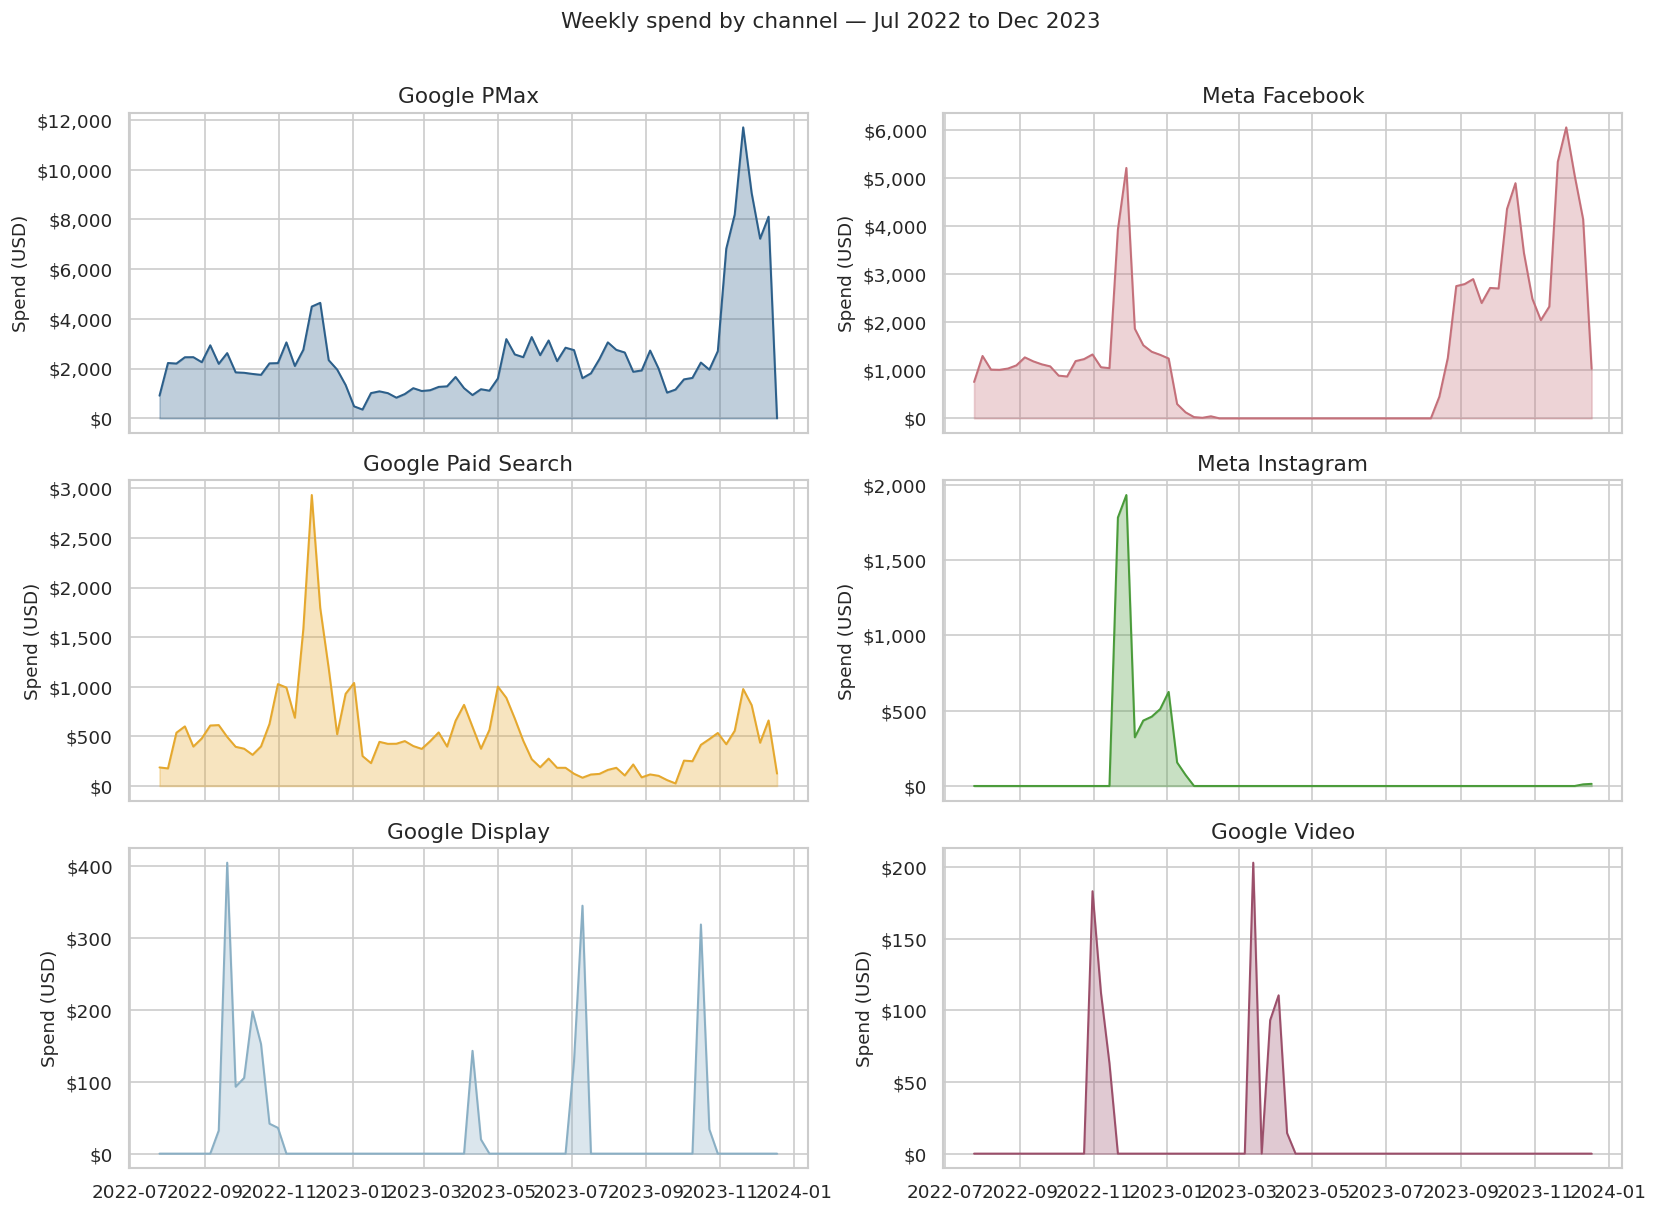

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

colors = ['#2C5F8A', '#C4707A', '#E5A82E', '#4A9B3A', '#8AAFC4', '#9B4F6A']
usd_formatter = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')

for ax, (col, label), color in zip(axes, spend_cols.items(), colors):
    ax.fill_between(df['week'], df[col], alpha=0.3, color=color)
    ax.plot(df['week'], df[col], color=color, linewidth=1.2)
    ax.yaxis.set_major_formatter(usd_formatter)
    ax.set_title(label)
    ax.set_ylabel('Spend (USD)')

plt.suptitle('Weekly spend by channel — Jul 2022 to Dec 2023', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.5.3. Spend mix composition over time

**What:** Stacked area chart showing the relative contribution of each channel to total weekly spend.  
**Why:** Detects shifts in media strategy over time. A changing mix complicates MMM estimation — if a channel's share changes dramatically mid-period, the model may struggle to separate its effect from confounding trends.

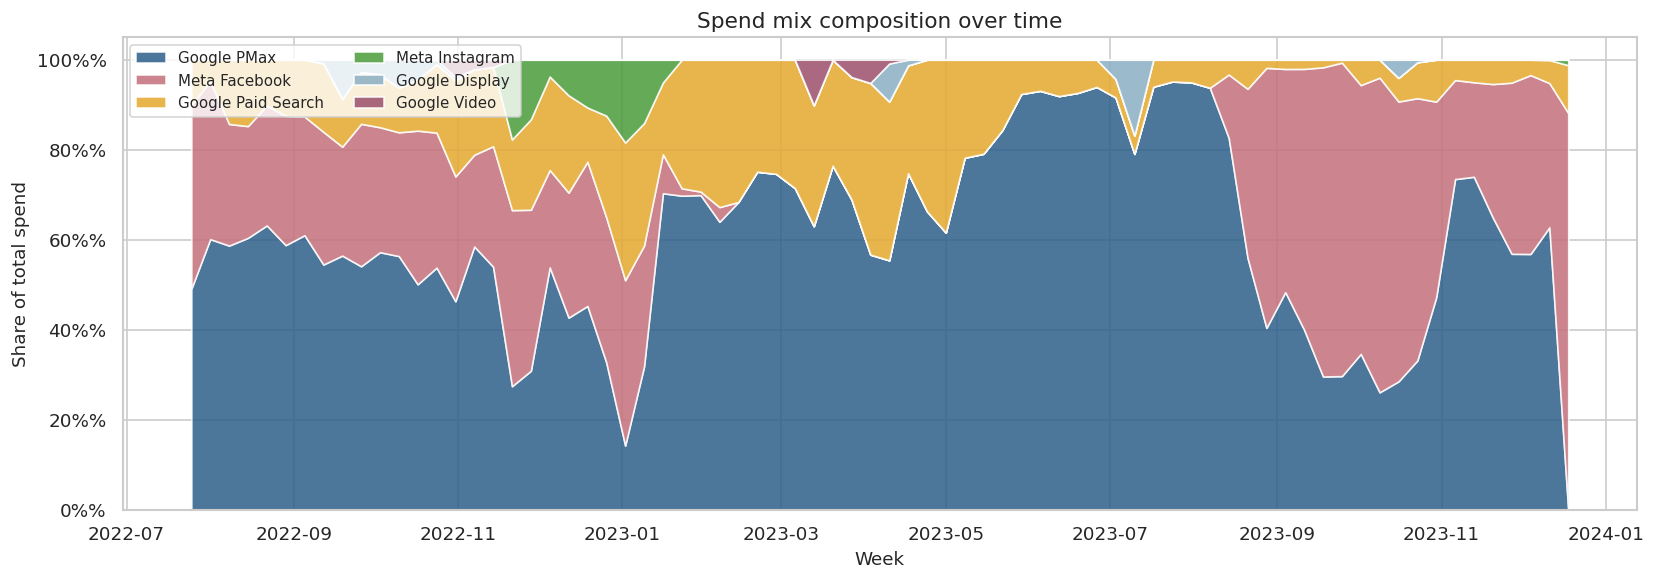

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

spend_data = df[list(spend_cols.keys())].copy()
spend_data.columns = list(spend_cols.values())
spend_pct = spend_data.div(spend_data.sum(axis=1), axis=0) * 100

colors = ['#2C5F8A', '#C4707A', '#E5A82E', '#4A9B3A', '#8AAFC4', '#9B4F6A']
ax.stackplot(df['week'], spend_pct.T, labels=spend_pct.columns, colors=colors, alpha=0.85)

pct_formatter = mticker.FuncFormatter(lambda x, _: f'{x:.0f}%%')
ax.yaxis.set_major_formatter(pct_formatter)
ax.set_ylabel('Share of total spend')
ax.set_xlabel('Week')
ax.set_title('Spend mix composition over time')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

---
## 2.6. CORRELATION ANALYSIS

**What:** Pearson correlation between each predictor variable and weekly revenue.  
**Why:** Identifies which variables have the strongest linear relationship with the target before modelling. High correlation does not imply causality — that is what the MMM estimates — but low correlation signals weak signal that may not survive regularization.

> **Interpretation guide:** |r| > 0.6 = strong, 0.3–0.6 = moderate, < 0.3 = weak.

In [11]:
# Variables to correlate with revenue
corr_vars = {
    'spend_total'   : 'Total spend',
    'spend_ps'      : 'Paid Search spend',
    'spend_pmax'    : 'PMax spend',
    'spend_fb'      : 'Facebook spend',
    'spend_ig'      : 'Instagram spend',
    'spend_display' : 'Display spend',
    'spend_video'   : 'Video spend',
    'clicks_branded': 'Branded search clicks',
    'clicks_organic': 'Organic search clicks',
    'clicks_email'  : 'Email clicks',
    'is_q4'         : 'Q4 flag',
    'is_bf_week'    : 'Black Friday flag',
}

corr_results = []
for col, label in corr_vars.items():
    if col in df.columns:
        r = df['revenue'].corr(df[col])
        strength = 'Strong' if abs(r) >= 0.6 else 'Moderate' if abs(r) >= 0.3 else 'Weak'
        corr_results.append({'Variable': label, 'r': r, 'Strength': strength})

df_corr = pd.DataFrame(corr_results).sort_values('r', ascending=False)

print(f"{'Variable':<28} {'r':>8}   {'Strength'}")
print("-" * 50)
for _, row in df_corr.iterrows():
    bar = '█' * int(abs(row['r']) * 20)
    print(f"{row['Variable']:<28} {row['r']:>8.3f}   {row['Strength']:<10} {bar}")

Variable                            r   Strength
--------------------------------------------------
Email clicks                    0.920   Strong     ██████████████████
Instagram spend                 0.803   Strong     ████████████████
Black Friday flag               0.722   Strong     ██████████████
Paid Search spend               0.593   Moderate   ███████████
Total spend                     0.483   Moderate   █████████
Facebook spend                  0.389   Moderate   ███████
Branded search clicks           0.304   Moderate   ██████
Q4 flag                         0.291   Weak       █████
PMax spend                      0.282   Weak       █████
Organic search clicks           0.266   Weak       █████
Video spend                    -0.113   Weak       ██
Display spend                  -0.132   Weak       ██


### 2.6.1. Correlation heatmap — spend channels

**What:** Heatmap of pairwise correlations between all spend channels.  
**Why:** High inter-channel correlations indicate multicollinearity — a key risk in MMM. When two channels are always activated together, the model cannot reliably separate their individual contributions. Channels with correlation > 0.7 between them require special treatment (regularization or hierarchical priors in Bayesian MMM).

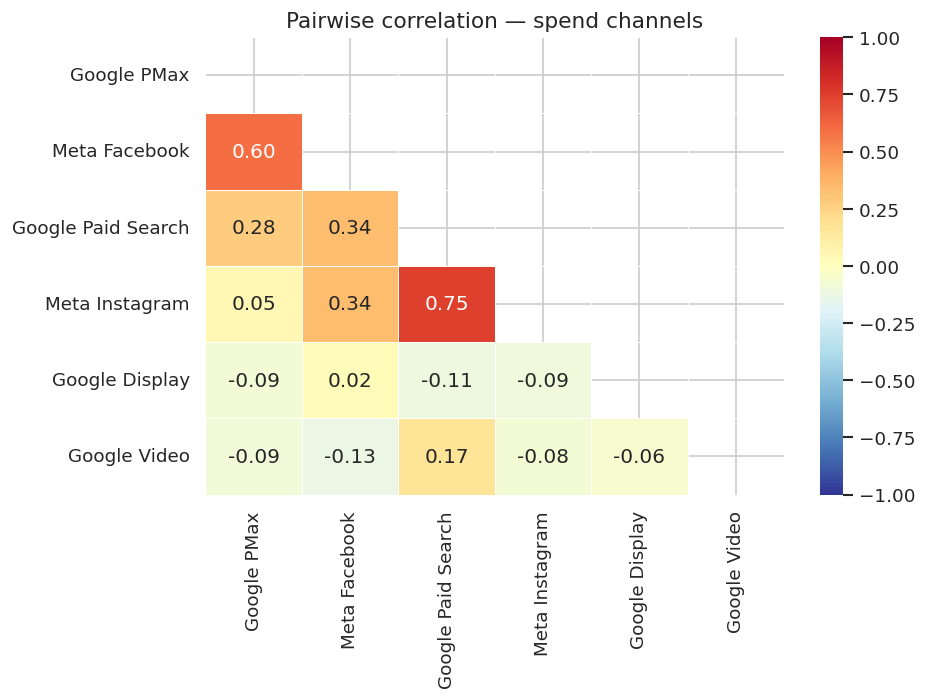

High multicollinearity pairs (|r| > 0.5):
  Google PMax ↔ Meta Facebook: r = 0.60
  Google Paid Search ↔ Meta Instagram: r = 0.75


In [12]:
spend_channel_cols = [c for c in spend_cols.keys() if c in df.columns]
corr_matrix = df[spend_channel_cols].corr()
corr_matrix.index = [spend_cols[c] for c in spend_channel_cols]
corr_matrix.columns = [spend_cols[c] for c in spend_channel_cols]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Pairwise correlation — spend channels')
plt.tight_layout()
plt.show()

# Flag high multicollinearity pairs
print("High multicollinearity pairs (|r| > 0.5):")
found = False
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: r = {r:.2f}")
            found = True
if not found:
    print("  None detected at threshold |r| > 0.5 ✓")

---
## 2.7. SEASONALITY ANALYSIS

**What:** Revenue patterns by month and by seasonal flag (Q4, Black Friday, Holiday).  
**Why:** Seasonality effects must be explicitly controlled for in the MMM — otherwise the model may attribute seasonal revenue lifts to whichever media channel happened to be active during that period, inflating its coefficient.

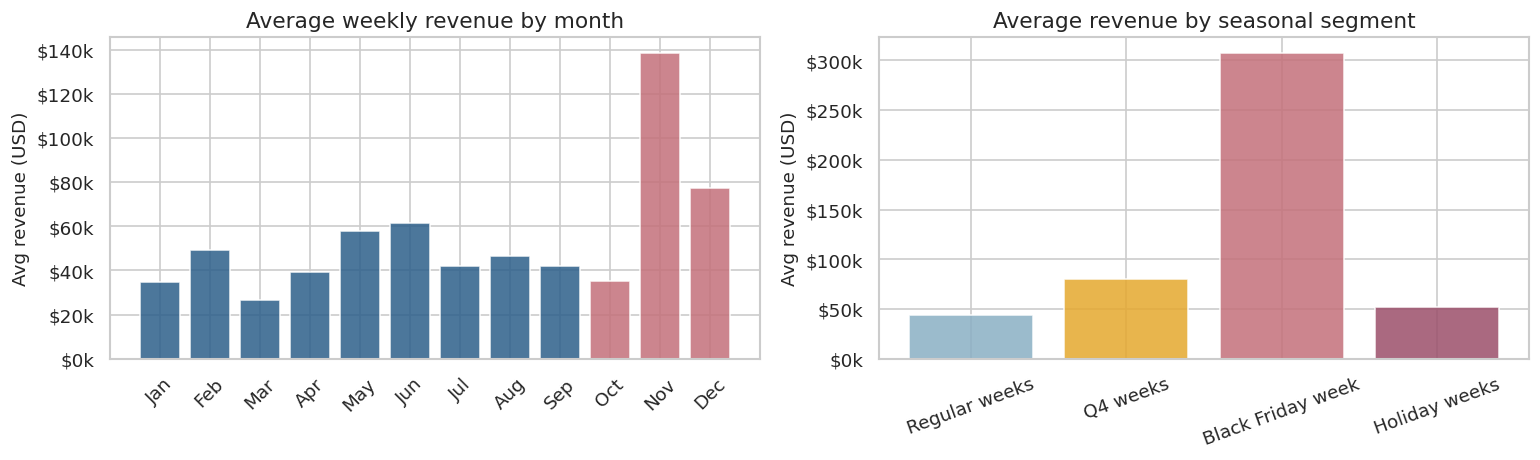

Revenue multipliers vs regular weeks:
  Regular weeks          : 1.00x  ($44,467)
  Q4 weeks               : 1.80x  ($80,170)
  Black Friday week      : 6.93x  ($308,010)
  Holiday weeks          : 1.17x  ($51,824)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Monthly average revenue
monthly = df.groupby('month')['revenue'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

axes[0].bar(monthly['month_name'], monthly['revenue'],
            color=['#C4707A' if m >= 10 else '#2C5F8A' for m in monthly['month']],
            edgecolor='white', alpha=0.85)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title('Average weekly revenue by month')
axes[0].set_ylabel('Avg revenue (USD)')
axes[0].tick_params(axis='x', rotation=45)

# Seasonal flag comparison
flag_data = {
    'Regular weeks'    : df[df['is_q4']==0]['revenue'].mean(),
    'Q4 weeks'         : df[df['is_q4']==1]['revenue'].mean(),
    'Black Friday week': df[df['is_bf_week']==1]['revenue'].mean(),
    'Holiday weeks'    : df[df['is_holiday']==1]['revenue'].mean(),
}
colors_flag = ['#8AAFC4', '#E5A82E', '#C4707A', '#9B4F6A']
axes[1].bar(flag_data.keys(), flag_data.values(), color=colors_flag, edgecolor='white', alpha=0.85)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_title('Average revenue by seasonal segment')
axes[1].set_ylabel('Avg revenue (USD)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("Revenue multipliers vs regular weeks:")
base = flag_data['Regular weeks']
for label, val in flag_data.items():
    print(f"  {label:<22} : {val/base:.2f}x  (${val:,.0f})")

---
## 2.8. OUTLIER DETECTION

**What:** Identifies weeks where revenue is unusually high or low relative to the rest of the series, using the IQR method.  
**Why:** Extreme outliers can distort MMM coefficient estimates if left untreated. In a Bayesian MMM they are partially absorbed by the prior, but in OLS-based models they need to be flagged and either explained by a known event (e.g. Black Friday) or treated with a dummy variable.

In [14]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['revenue'] < lower) | (df['revenue'] > upper)][
    ['week', 'revenue', 'is_q4', 'is_bf_week', 'is_holiday', 'spend_total']
].copy()
outliers['explained'] = outliers.apply(
    lambda r: 'Black Friday' if r['is_bf_week'] else
              'Holiday' if r['is_holiday'] else
              'Q4' if r['is_q4'] else '⚠ Unexplained',
    axis=1
)

print(f"IQR bounds: ${lower:,.0f}  —  ${upper:,.0f}")
print(f"Outlier weeks detected: {len(outliers)}")
print()
if len(outliers) > 0:
    print(outliers[['week','revenue','spend_total','explained']].to_string(index=False))
    unexplained = outliers[outliers['explained'] == '⚠ Unexplained']
    if len(unexplained) > 0:
        print(f"\n⚠  {len(unexplained)} unexplained outlier(s) — consider adding event dummy variables in the MMM.")
    else:
        print("\n✓  All outliers explained by known seasonal events — no additional dummies required.")

IQR bounds: $-4,550  —  $97,477
Outlier weeks detected: 6

      week    revenue  spend_total    explained
2022-11-21 474,930.36    10,070.88 Black Friday
2022-11-28 215,196.19    14,603.12           Q4
2022-12-05 130,129.29     8,632.40           Q4
2022-12-12 111,967.56     5,499.79           Q4
2023-11-20 141,090.03    18,029.20 Black Friday
2023-11-27 103,988.70    15,943.16           Q4

✓  All outliers explained by known seasonal events — no additional dummies required.


---
## 2.9. FEATURE SELECTION CRITERIA

**What:** Consolidates findings from sections 2.5, 2.6 and 2.8 into a feature selection decision table for the MMM.  
**Why:** With only 74 weekly observations, the MMM can reliably support a maximum of 8–10 predictors. Including too many variables — especially those with low coverage or near-zero correlation with revenue — increases the risk of overfitting and produces unreliable coefficients. This table makes the selection criteria explicit and traceable.

In [15]:
feature_decisions = [
    ('spend_pmax',    'Google PMax spend',       'IN',  '74/74 weeks, 57% of spend, r=0.28'),
    ('spend_fb',      'Meta Facebook spend',     'IN',  '48/74 weeks, 29% of spend, r=0.39'),
    ('spend_ps',      'Google Paid Search spend','IN',  '71/74 weeks, 11% of spend, r=0.58'),
    ('spend_ig',      'Meta Instagram spend',    'IN',  '11/74 weeks, 2% of spend, r=0.80 — use with caution'),
    ('spend_display', 'Google Display spend',    'OUT', '< 30% coverage, < 1% spend share — insufficient variation'),
    ('spend_video',   'Google Video spend',      'OUT', '< 30% coverage, < 1% spend share — insufficient variation'),
    ('clicks_branded','Branded search clicks',   'IN',  'Proxy for brand awareness accumulated from media'),
    ('clicks_organic','Organic search clicks',   'IN',  'Baseline signal — separates organic from paid'),
    ('clicks_email',  'Email clicks',            'IN',  'r=0.92 — strong signal, low spend dependency'),
    ('is_q4',        'Q4 seasonal flag',         'IN',  'Revenue multiplier confirmed in 2.7'),
    ('is_bf_week',   'Black Friday flag',        'IN',  'r=0.72, largest outlier explained'),
    ('is_holiday',   'Holiday flag',             'IN',  'Controls for Christmas/New Year weeks'),
]

print(f"{'Variable':<28} {'Decision':>10}   Rationale")
print("-" * 85)
for col, label, decision, rationale in feature_decisions:
    icon = '✓' if decision == 'IN' else '✗'
    print(f"{label:<28} {icon} {decision:<8}   {rationale}")

print()
n_in = sum(1 for _, _, d, _ in feature_decisions if d == 'IN')
print(f"Variables selected for MMM: {n_in} / {len(feature_decisions)}")
print("Within the 8–10 variable budget recommended for 74 weekly observations ✓" if n_in <= 10 else
      f"⚠  {n_in} variables exceeds recommended budget — consider further reduction")

Variable                       Decision   Rationale
-------------------------------------------------------------------------------------
Google PMax spend            ✓ IN         74/74 weeks, 57% of spend, r=0.28
Meta Facebook spend          ✓ IN         48/74 weeks, 29% of spend, r=0.39
Google Paid Search spend     ✓ IN         71/74 weeks, 11% of spend, r=0.58
Meta Instagram spend         ✓ IN         11/74 weeks, 2% of spend, r=0.80 — use with caution
Google Display spend         ✗ OUT        < 30% coverage, < 1% spend share — insufficient variation
Google Video spend           ✗ OUT        < 30% coverage, < 1% spend share — insufficient variation
Branded search clicks        ✓ IN         Proxy for brand awareness accumulated from media
Organic search clicks        ✓ IN         Baseline signal — separates organic from paid
Email clicks                 ✓ IN         r=0.92 — strong signal, low spend dependency
Q4 seasonal flag             ✓ IN         Revenue multiplier confirmed in 

---
## 2.10. EDA SUMMARY

### 2.10.1. Key findings

| # | Finding | Implication for MMM |
|:--|:--------|:--------------------|
| 1 | Revenue CV = 99.7% — extreme weekly volatility driven by Black Friday | Log-transform revenue before modelling to stabilize variance |
| 2 | Google PMax accounts for 57% of total spend | Largest contributor — its coefficient will dominate the model |
| 3 | Meta Instagram active only 11/74 weeks | Include with caution — Bayesian prior needed to stabilize coefficient |
| 4 | Google Display and Video < 30% coverage | Exclude from MMM — insufficient variation to estimate reliable coefficients |
| 5 | Email clicks r = 0.92 with revenue | Strong signal — likely captures CRM-driven repeat purchase, not media effect |
| 6 | No unexplained outliers | Black Friday and holiday dummies fully account for extreme weeks |
| 7 | ROAS declined from 15.8x (2022) to 11.9x (2023) | Increasing inefficiency — MMM will quantify contribution by channel to diagnose |
| 8 | Low multicollinearity between main channels | PMax and Facebook are not strongly co-activated — coefficients separable |

### 2.10.2. Next steps

The EDA confirms the dataset is suitable for MMM modelling with the following decisions locked in:

1. **Target variable:** `log(revenue)` — log-transformation to address right skew and stabilize variance.
2. **Media variables:** PMax, Facebook, Paid Search, Instagram (with cautious prior) — after Adstock and Hill saturation transformation.
3. **Excluded channels:** Display and Video — insufficient weekly coverage.
4. **Control variables:** Branded search clicks, organic search clicks, email clicks, Q4 flag, Black Friday flag, holiday flag.
5. **Model type:** Bayesian MMM (PyMC) — preferred over OLS given the limited 74-week sample and the need to incorporate industry priors for low-coverage channels.

---

**Next notebook:** `03_mmm_transformation.ipynb` — Adstock decay, Hill saturation curves and final feature matrix construction.


In [16]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"\nDataset          : {len(df)} weekly observations")
print(f"Period           : {df['week'].min().date()} → {df['week'].max().date()}")
print(f"Revenue range    : ${df['revenue'].min():,.0f} – ${df['revenue'].max():,.0f}")
print(f"Revenue CV%       : {df['revenue'].std()/df['revenue'].mean()*100:.1f}%%")
print(f"Total ad spend   : ${df['spend_total'].sum():,.0f}")
print(f"Overall ROAS     : {df['revenue'].sum()/df['spend_total'].sum():.2f}x")
print(f"\nFeatures for MMM : {n_in} variables selected")
print(f"Outliers         : {len(outliers)} weeks (all explained by seasonal events)")
print(f"\nNext notebook    : 03_mmm_transformation.ipynb")

EDA SUMMARY

Dataset          : 74 weekly observations
Period           : 2022-07-25 → 2023-12-18
Revenue range    : $10,340 – $474,930
Revenue CV%       : 103.4%%
Total ad spend   : $327,225
Overall ROAS     : 12.78x

Features for MMM : 10 variables selected
Outliers         : 6 weeks (all explained by seasonal events)

Next notebook    : 03_mmm_transformation.ipynb
